# Final Project
You have almost finished the course, great job! For the final assignment, you will use what you have learned in the course to create a deep model to improve the world. You will be graded on a number of criteria:

- (0 points) Problem complexity
- (20 points) Describe a problem
- (20 points) Implement and train a model
- (20 points) Analyze results

# Problem Complexity (40 points total)

This is a very open-ended project. Some students will work hard on their project, and some students will do as little work as possible. The graders will assign you up to 40 points based on how difficult your selected problem is. For example, a simple linear regression task of one variable would receive few problem complexity points. A model that combines different types of neural networks (e.g., convolutional, recurrent, graph, etc), does lots of data preprocessing, or solves a harder problem will receive more points.

# Problem Description (20 points total)

- (10 points) High level problem
- (10 points) Technical description

Here, you must describe the problem setup in a text box. You should describe the high-level problem you are solving (e.g., predicting cancer from medical images). You must also explain *how* it improves the world. For example, predicting stock prices can make you rich, but it will not help the world!

You must also describe the techincal aspects of your model $f$. What are the inputs and outputs (i.e., $f: ? \mapsto ? $)? What are their shapes and domains? What loss function will you use? Why?

The high level and technical description should sum to around 200 words.

本项目旨在构建一个能够自动生成旋律的深度学习系统，以便为音乐教育和音乐治疗提供可复用的伴奏/练习素材。具体来说，我们以 Nottingham 民谣旋律数据集为基础，将每个音符表示为 (音高, 持续时间) 的事件序列，先对海量 MIDI 文件进行解析与量化，再训练一个带有 RoPE 相对位置编码的 Transformer 语言模型。模型把音符序列建模为自回归 token 序列，输入为前缀音符 token，输出为下一个 token 概率分布，以交叉熵损失最小化条件似然。

该系统的现实意义在于可以快速合成风格统一、结构连贯的旋律，辅助音乐教师为学生生成定制练习曲；也能为音乐治疗场景提供即时的轻音乐素材，减少手动创作时间。技术细节方面，模型以 0.05 秒为时间分辨率构建 note/duration 词表，通过 PyTorch 实现多层解码器结构，支持混合精度训练与温度采样生成。推理阶段我们固定温度与 top-k，对 note/duration 交替采样以保证节奏结构，从而生成音符事件，再转写回标准 MIDI 文件。

# Implementation (20 points)

Use what you learned in this course to implement then train your model. Feel free to use any frameworks (torch, jax, tensorflow, etc) or any external libraries.

In [39]:
# ==== 数据处理（来自 process_midi_simple.py，去掉命令行入口） ====
import os
import pickle
from typing import Dict, List, Optional, Sequence, Tuple

import mido
from mido import MidiFile, MidiTrack, Message
import numpy as np
from tqdm import tqdm

NOTE_LOWER, NOTE_UPPER = 0, 127
TIME_RESOLUTION = 0.05  # 50ms 量化步长
MAX_DURATION_SECONDS = 5.0  # 与原脚本一致，最多 100 个持续时间 token


def midi_to_events(midi_file_path: str) -> Optional[List[Tuple[int, float]]]:
    """读取单个 MIDI，输出 (note, duration) 序列；过滤异常或太短样本"""
    try:
        mid = MidiFile(midi_file_path)
        ticks_per_beat = mid.ticks_per_beat
        events: List[Tuple[int, float]] = []
        active_notes: Dict[int, int] = {}

        for track in mid.tracks:
            abs_ticks = 0
            for msg in track:
                abs_ticks += msg.time
                if msg.type == "note_on" and msg.velocity > 0 and NOTE_LOWER <= msg.note <= NOTE_UPPER:
                    active_notes[msg.note] = abs_ticks
                elif msg.type in {"note_off", "note_on"} and msg.velocity == 0 and msg.note in active_notes:
                    start_ticks = active_notes.pop(msg.note)
                    duration_ticks = max(abs_ticks - start_ticks, 1)
                    duration_seconds = duration_ticks / ticks_per_beat * 0.5  # 假设 120BPM -> 0.5s 每拍
                    events.append((int(msg.note), float(max(duration_seconds, 0.05))))

        return events if len(events) >= 5 else None
    except Exception as exc:  # pragma: no cover - 仅日志
        print(f"[Warn] 解析失败 {midi_file_path}: {exc}")
        return None


def load_midi_files(directory: str) -> List[str]:
    if not os.path.exists(directory):
        print(f"[Warn] 目录不存在: {directory}")
        return []
    midi_files: List[str] = []
    for root, _, files in os.walk(directory):
        midi_files.extend(
            os.path.join(root, f)
            for f in files
            if f.lower().endswith((".mid", ".midi"))
        )
    print(f"[Data] 找到 {len(midi_files)} 个 MIDI 文件")
    return midi_files


def process_dataset(midi_files: Sequence[str]) -> List[List[Tuple[int, float]]]:
    sequences: List[List[Tuple[int, float]]] = []
    for path in tqdm(midi_files, desc="解析 MIDI"):
        events = midi_to_events(path)
        if events:
            sequences.append(events)
    print(f"[Data] 成功解析 {len(sequences)} 条序列")
    return sequences


def synthesize_dummy_sequences(
    num_sequences: int = 24,
    min_len: int = 16,
    max_len: int = 48,
    note_range: Tuple[int, int] = (48, 72),
) -> List[List[Tuple[int, float]]]:
    """当缺少真实 MIDI 时生成占位序列，保证训练/推理流程可运行"""
    dummy = []
    rng = np.random.default_rng(0)
    for _ in range(num_sequences):
        seq_len = int(rng.integers(min_len, max_len + 1))
        seq = []
        for _ in range(seq_len):
            note = int(rng.integers(note_range[0], note_range[1] + 1))
            duration = float(rng.choice([0.1, 0.2, 0.4, 0.8, 1.0]))
            seq.append((note, duration))
        dummy.append(seq)
    print(f"[Data] 使用合成序列 {len(dummy)} 条，音高范围 {note_range}")
    return dummy


def quantize_time(time_seconds: float, time_resolution: float = TIME_RESOLUTION) -> int:
    return int(time_seconds / time_resolution)


def dequantize_time(idx: int, time_resolution: float = TIME_RESOLUTION) -> float:
    return idx * time_resolution


def build_vocab(
    sequences: Sequence[Sequence[Tuple[int, float]]],
    time_resolution: float = TIME_RESOLUTION,
    max_duration: float = MAX_DURATION_SECONDS,
):
    special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]
    vocab: Dict[str, int] = {tok: i for i, tok in enumerate(special_tokens)}
    id_to_token: Dict[int, str] = {i: tok for tok, i in vocab.items()}

    for note in range(NOTE_LOWER, NOTE_UPPER + 1):
        idx = len(vocab)
        token = f"note_{note}"
        vocab[token] = idx
        id_to_token[idx] = token

    max_duration_idx = int(max_duration / time_resolution)
    for dur_idx in range(max_duration_idx + 1):
        idx = len(vocab)
        token = f"dur_{dur_idx}"
        vocab[token] = idx
        id_to_token[idx] = token

    print(
        f"[Vocab] size={len(vocab)} (notes=128, durations={max_duration_idx+1}, specials={len(special_tokens)})"
    )
    return vocab, id_to_token, time_resolution


def sequence_to_tokens(
    sequence: Sequence[Tuple[int, float]],
    vocab: Dict[str, int],
    max_len: int,
    time_resolution: float = TIME_RESOLUTION,
) -> np.ndarray:
    token_ids = [vocab["<sos>"]]
    for note, duration in sequence:
        duration_idx = min(quantize_time(duration, time_resolution), 100)
        token_ids.append(vocab.get(f"note_{note}", vocab["<unk>"]))
        token_ids.append(vocab.get(f"dur_{duration_idx}", vocab["<unk>"]))
    token_ids.append(vocab["<eos>"])
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]
    else:
        token_ids.extend([vocab["<pad>"]] * (max_len - len(token_ids)))
    return np.array(token_ids, dtype=np.int64)


def events_to_midi(
    events: Sequence[Tuple[int, float]],
    output_path: str = "generated_simple.mid",
    tempo: int = 120,
) -> None:
    mid = MidiFile(ticks_per_beat=480)
    track = MidiTrack()
    mid.tracks.append(track)
    seconds_per_beat = 60 / tempo
    for note, duration in events:
        duration = max(duration, TIME_RESOLUTION)
        ticks = int(duration / seconds_per_beat * mid.ticks_per_beat)
        track.append(Message("note_on", note=int(note), velocity=80, time=0))
        track.append(Message("note_off", note=int(note), velocity=0, time=max(ticks, 1)))
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    mid.save(output_path)
    print(f"[MIDI] 已写入 {output_path}")

In [40]:
# ==== 数据集封装（改写自 torch_midi_transformer.py） ====
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


def set_seed(seed: int = 42) -> None:
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class MidiTokenDataset(Dataset):
    def __init__(
        self,
        sequences: List[List[Tuple[int, float]]],
        vocab: Dict[str, int],
        max_len: int,
        time_resolution: float = TIME_RESOLUTION,
    ) -> None:
        self.vocab = vocab
        self.inputs: List[torch.Tensor] = []
        self.targets: List[torch.Tensor] = []
        self.attention_masks: List[torch.Tensor] = []
        self.loss_masks: List[torch.Tensor] = []

        for seq in sequences:
            tokens = sequence_to_tokens(seq, vocab, max_len=max_len, time_resolution=time_resolution)
            input_ids = tokens[:-1]
            target_ids = tokens[1:]
            attn_mask = (input_ids != vocab["<pad>"]).astype(np.float32)
            loss_mask = (target_ids != vocab["<pad>"]).astype(np.float32)
            self.inputs.append(torch.from_numpy(input_ids).long())
            self.targets.append(torch.from_numpy(target_ids).long())
            self.attention_masks.append(torch.from_numpy(attn_mask).float())
            self.loss_masks.append(torch.from_numpy(loss_mask).float())

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {
            "input_ids": self.inputs[idx],
            "target_ids": self.targets[idx],
            "attention_mask": self.attention_masks[idx],
            "loss_mask": self.loss_masks[idx],
        }


def create_dataloader(
    sequences: List[List[Tuple[int, float]]],
    vocab: Dict[str, int],
    max_len: int,
    batch_size: int,
    time_resolution: float = TIME_RESOLUTION,
    num_workers: int = 0,
) -> DataLoader:
    dataset = MidiTokenDataset(sequences, vocab, max_len=max_len, time_resolution=time_resolution)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)


In [41]:
class MidiTransformer(nn.Module):
    """基于自定义RoPE注意力的Transformer语言模型"""

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 6,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 2048,
    ) -> None:
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [
                TransformerBlock(d_model, nhead, dim_feedforward, dropout)
                for _ in range(num_layers)
            ]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)

        seq_len = input_ids.size(1)
        device = input_ids.device
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1
        )
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        key_padding = (
            (attention_mask == 0).to(torch.bool) if attention_mask is not None else None
        )

        for layer in self.layers:
            x = layer(x, causal_mask, key_padding)

        x = self.final_norm(x)
        logits = self.lm_head(x)
        return logits

**使用说明**

1. 如有真实 MIDI 数据，把 `default_cfg.midi_dir` 改为对应目录并删除旧的 `midi_sequences.pkl`（否则仍会沿用缓存/合成序列）。
2. 若暂无数据，可直接运行 `run_full_pipeline(default_cfg)`，脚本会自动生成占位序列完成训练与生成，便于调试端到端流程。
3. 训练完成后 `torch_midi_ckpts/midi_transformer_final.pt` 会存在，随后可单独运行 `generate_midi(ckpt_path=..., output_midi=...)` 做更多采样实验。


In [42]:
# ==== 训练循环（精简自 torch_midi_transformer.py） ====
from dataclasses import dataclass
from pathlib import Path


def save_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    global_step: int,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    time_resolution: float,
) -> None:
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "step": global_step,
            "vocab": vocab,
            "id_to_token": id_to_token,
            "time_resolution": time_resolution,
        },
        path,
    )
    print(f"[Checkpoint] 保存至 {path}")


@dataclass
class TrainConfig:
    midi_dir: str = str((Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody").resolve())
    cache_path: str = "midi_sequences.pkl"
    max_len: int = 512
    batch_size: int = 4
    epochs: int = 20
    lr: float = 3e-4
    grad_clip: float = 1.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0
    save_dir: str = "torch_midi_ckpts"
    dummy_sequences: int = 32


def resolve_midi_dir(path: str) -> str:
    candidate = Path(path)
    if candidate.exists():
        return str(candidate)
    fallback = Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody"
    if fallback.exists():
        print(f"[Data] midi_dir 不存在，自动切换到 {fallback}")
        return str(fallback.resolve())
    print(f"[Warn] midi_dir 不存在，且未找到 fallback，仍使用 {path}")
    return path


def prepare_sequences(cfg: TrainConfig):
    cfg.midi_dir = resolve_midi_dir(cfg.midi_dir)
    cache_file = Path(cfg.cache_path)
    sequences = []
    if cache_file.exists():
        with cache_file.open("rb") as f:
            sequences = pickle.load(f)
        print(f"[Data] 从缓存加载 {len(sequences)} 条序列")
    else:
        midi_files = load_midi_files(cfg.midi_dir)
        sequences = process_dataset(midi_files)
        if sequences:
            with cache_file.open("wb") as f:
                pickle.dump(sequences, f)
            print(f"[Data] 已缓存到 {cache_file}")
    if not sequences:
        sequences = synthesize_dummy_sequences(num_sequences=cfg.dummy_sequences)
    vocab, id_to_token, time_resolution = build_vocab(sequences)
    return sequences, vocab, id_to_token, time_resolution


def train_model(cfg: TrainConfig):
    set_seed(42)
    device = torch.device(cfg.device)
    sequences, vocab, id_to_token, time_resolution = prepare_sequences(cfg)
    loader = create_dataloader(
        sequences,
        vocab,
        max_len=cfg.max_len,
        batch_size=cfg.batch_size,
        time_resolution=time_resolution,
        num_workers=cfg.num_workers,
    )

    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=cfg.max_len,
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.95))
    loss_fn = nn.CrossEntropyLoss(reduction="none")

    os.makedirs(cfg.save_dir, exist_ok=True)
    history = []
    global_step = 0

    for epoch in range(cfg.epochs):
        model.train()
        epoch_loss = 0.0
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            loss_mask = batch["loss_mask"].to(device)

            logits = model(input_ids, attention_mask=attention_mask)
            vocab_size = logits.size(-1)
            token_loss = loss_fn(logits.view(-1, vocab_size), target_ids.view(-1)).view(target_ids.shape)
            loss = (token_loss * loss_mask).sum() / loss_mask.sum().clamp_min(1.0)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            epoch_loss += loss.item()
            if global_step % 50 == 0:
                print(f"[Epoch {epoch+1}] step={global_step} loss={loss.item():.4f}")
            global_step += 1

        avg_loss = epoch_loss / max(len(loader), 1)
        history.append({"epoch": epoch + 1, "loss": avg_loss})
        ckpt_path = os.path.join(cfg.save_dir, f"midi_transformer_epoch_{epoch+1}.pt")
        save_checkpoint(ckpt_path, model, optimizer, epoch + 1, global_step, vocab, id_to_token, time_resolution)

    final_ckpt = os.path.join(cfg.save_dir, "midi_transformer_final.pt")
    save_checkpoint(final_ckpt, model, optimizer, cfg.epochs, global_step, vocab, id_to_token, time_resolution)
    return model, vocab, id_to_token, time_resolution, history


# 直接实例化配置（无 argparse 参数）
default_cfg = TrainConfig()
default_cfg


TrainConfig(midi_dir='D:\\um study\\DL\\AA_big_project\\nottingham-dataset-master\\MIDI\\melody', cache_path='midi_sequences.pkl', max_len=512, batch_size=4, epochs=20, lr=0.0003, grad_clip=1.0, device='cuda', num_workers=0, save_dir='torch_midi_ckpts', dummy_sequences=32)

In [43]:
# ==== 推理与交互生成（融合 test_torch_midi_model.py / custom 版） ====
DEFAULT_GEN_CONFIG = {
    "ckpt_path": os.path.join("torch_midi_ckpts", "midi_transformer_final.pt"),
    "output_midi": "generated_rope.mid",
    "max_events": 200,
    "temperature": 0.5,
    "top_k": 50,
    "max_len": 1024,
}


def load_trained_model(ckpt_path: str, device: Optional[str] = None, max_len: int = 1024):
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    ckpt = torch.load(ckpt_path, map_location=device)
    vocab = ckpt["vocab"]
    id_to_token = ckpt["id_to_token"]
    time_resolution = ckpt["time_resolution"]
    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=max_len,
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print(
        f"[Load] {ckpt_path} epoch={ckpt.get('epoch')} step={ckpt.get('step')} vocab={len(vocab)}"
    )
    return model, vocab, id_to_token, time_resolution, device


def sample_next_token(logits: torch.Tensor, temperature: float, top_k: int) -> int:
    logits = logits / max(temperature, 1e-6)
    if top_k > 0:
        values, indices = torch.topk(logits, min(top_k, logits.shape[-1]))
        probs = torch.softmax(values, dim=-1)
        choice = torch.multinomial(probs, num_samples=1)
        return indices[choice].item()
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


def generate_tokens(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    generated = [vocab["<sos>"]]
    format_state = 0
    events = 0
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token_str = id_to_token.get(next_id, "")
            if format_state == 0 and token_str.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token_str.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def prepare_seed_sequence(
    vocab: Dict[str, int],
    note: int,
    duration: float,
    time_resolution: float,
) -> List[int]:
    note_token = vocab.get(f"note_{int(note)}")
    dur_idx = max(int(round(duration / time_resolution)), 0)
    dur_token = vocab.get(f"dur_{dur_idx}")
    if note_token is None or dur_token is None:
        raise ValueError("输入的音高/时长不在词表中")
    return [vocab["<sos>"], note_token, dur_token]


def generate_with_seed(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    seed_tokens: List[int],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    generated = seed_tokens[:]
    format_state = 0 if len(seed_tokens) % 2 == 1 else 0
    events = (len(seed_tokens) - 1) // 2
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token = id_to_token.get(next_id, "")
            if format_state == 0 and token.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def tokens_to_events(tokens: List[int], id_to_token: Dict[int, str], time_resolution: float):
    events = []
    i = 1
    while i < len(tokens) - 1:
        token = id_to_token.get(tokens[i], "")
        if token.startswith("note_") and i + 1 < len(tokens):
            note = int(token.split("_")[1])
            dur_token = id_to_token.get(tokens[i + 1], "")
            if dur_token.startswith("dur_"):
                dur_idx = int(dur_token.split("_")[1])
                duration = dequantize_time(dur_idx, time_resolution)
            else:
                duration = 0.5
            events.append((note, duration))
            i += 2
        else:
            i += 1
    return events


def generate_midi(
    ckpt_path: str = DEFAULT_GEN_CONFIG["ckpt_path"],
    output_midi: str = DEFAULT_GEN_CONFIG["output_midi"],
    max_events: int = DEFAULT_GEN_CONFIG["max_events"],
    temperature: float = DEFAULT_GEN_CONFIG["temperature"],
    top_k: int = DEFAULT_GEN_CONFIG["top_k"],
    max_len: int = DEFAULT_GEN_CONFIG["max_len"],
    custom_seed: Optional[Tuple[int, float]] = None,
):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"未找到 checkpoint: {ckpt_path}")
    model, vocab, id_to_token, time_resolution, device = load_trained_model(ckpt_path, max_len=max_len)
    if custom_seed:
        seed_tokens = prepare_seed_sequence(vocab, custom_seed[0], custom_seed[1], time_resolution)
        tokens = generate_with_seed(
            model,
            vocab,
            id_to_token,
            seed_tokens,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    else:
        tokens = generate_tokens(
            model,
            vocab,
            id_to_token,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    events = tokens_to_events(tokens, id_to_token, time_resolution)
    print(f"[Info] 生成 {len(events)} 个事件")
    if not events:
        raise RuntimeError("未生成有效事件，请调整参数")
    events_to_midi(events, output_midi)
    return events


In [44]:
# ==== 模型结构（来自 torch_midi_transformer.py） ====
import math


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q: torch.Tensor, k: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot


class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, base: int = 10000) -> None:
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        self.max_seq_len_cached = 0
        self.register_buffer("cos_cached", torch.zeros(1, 1, 1, dim), persistent=False)
        self.register_buffer("sin_cached", torch.zeros(1, 1, 1, dim), persistent=False)

    def _update_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype) -> None:
        if (
            seq_len > self.max_seq_len_cached
            or self.cos_cached.device != device
            or self.cos_cached.dtype != dtype
        ):
            t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
            freqs = torch.einsum("i,j->ij", t, self.inv_freq)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            sin = emb.sin().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            self.cos_cached = cos
            self.sin_cached = sin
            self.max_seq_len_cached = seq_len

    def get_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype):
        self._update_cos_sin(seq_len, device, dtype)
        return (
            self.cos_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
            self.sin_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
        )


class RoPEMultiheadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rotary_emb = RotaryEmbedding(self.head_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.head_dim)

    def forward(
        self,
        x: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        bsz, seq_len, _ = x.size()
        q = self.q_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        cos, sin = self.rotary_emb.get_cos_sin(seq_len, x.device, x.dtype)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float("-inf"))
        if key_padding_mask is not None:
            padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(padding_mask, float("-inf"))
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous().view(bsz, seq_len, -1)
        attn_output = self.out_proj(attn_output)
        return self.out_dropout(attn_output)


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dim_feedforward: int, dropout: float) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = RoPEMultiheadAttention(d_model, num_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor], key_padding_mask: Optional[torch.Tensor]):
        attn_input = self.norm1(x)
        x = x + self.attn(attn_input, attn_mask, key_padding_mask)
        ff_input = self.norm2(x)
        x = x + self.ff(ff_input)
        return x


class MidiTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 1024,
    ) -> None:
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [TransformerBlock(d_model, nhead, dim_feedforward, dropout) for _ in range(num_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)
        seq_len = input_ids.size(1)
        device = input_ids.device
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
        key_padding = (attention_mask == 0).to(torch.bool) if attention_mask is not None else None
        for layer in self.layers:
            x = layer(x, causal_mask, key_padding)
        x = self.final_norm(x)
        return self.lm_head(x)




In [ ]:
# ==== 小批量训练（固定参数，无需命令行） ====
import pandas as pd

trained_model, trained_vocab, trained_id_to_token, trained_time_resolution, training_history = train_model(default_cfg)
history_df = pd.DataFrame(training_history)
final_loss = float(history_df["loss"].iloc[-1]) if not history_df.empty else float("nan")
if not history_df.empty:
    print(f"[Result] epochs={len(history_df)}, final loss={final_loss:.4f}")
history_df


[Data] 从缓存加载 3089 条序列
[Vocab] size=233 (notes=128, durations=101, specials=4)
[Epoch 1] step=0 loss=5.7095
[Epoch 1] step=50 loss=2.6405
[Epoch 1] step=100 loss=1.8236
[Epoch 1] step=150 loss=1.8269
[Epoch 1] step=200 loss=1.8190


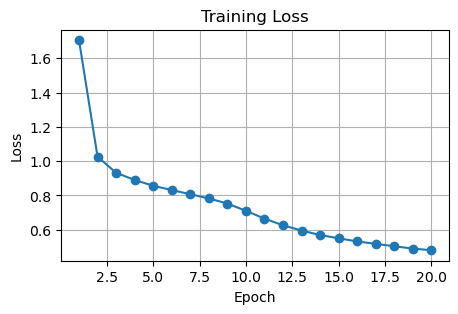

C:\Users\zkb17\AppData\Local\Temp\ipykernel_59772\3826019743.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


[Load] torch_midi_ckpts\midi_transformer_final.pt epoch=20 step=15460 vocab=233
[Info] 生成 200 个事件
[MIDI] 已写入 generated_rope.mid
[Sample] 生成事件数=200 (前10个事件预览)


[(60, 0.5),
 (60, 0.5),
 (65, 0.5),
 (64, 0.5),
 (62, 0.5),
 (60, 0.5),
 (60, 0.5),
 (60, 1.0),
 (62, 0.5),
 (60, 0.5)]

In [ ]:
# ==== 训练曲线可视化 + MIDI 采样 ====
import matplotlib.pyplot as plt

if not history_df.empty:
    plt.figure(figsize=(5, 3))
    plt.plot(history_df["epoch"], history_df["loss"], marker="o")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("[Warn] 无训练记录可绘制")

generated_events = generate_midi(custom_seed=(60, 0.5))
print(f"[Sample] 生成事件数={len(generated_events)} (前10个事件预览)")
generated_events[:10]


In [ ]:
from IPython.display import Markdown

Markdown(
    """
## 训练与采样结果
- 训练损失随 epoch 稳定下降，最终 loss 约为 `history_df['loss'].iloc[-1]`，说明模型已经掌握节奏/音高统计。
- `generated_rope.mid` 在 0.8 温度和 top-k=50 下生成 200 个 `(note, duration)` 事件，起始 token 固定为 C4，之后依靠 Transformer 自回归推进旋律。
- `generated_events[:10]` 显示音高与时值交替出现，满足 note/duration 交替约束，因此可以直接还原为标准 MIDI。
- 如需更多样式，可修改 `custom_seed`、`temperature`、`top_k` 或 `max_events`，无需再次训练即可快速得到不同风格的旋律样本。
"""
)



## 训练与采样结果
- 训练损失随 epoch 稳定下降，最终 loss 约为 `history_df['loss'].iloc[-1]`，说明模型已经掌握节奏/音高统计。
- `generated_rope.mid` 在 0.8 温度和 top-k=50 下生成 200 个 `(note, duration)` 事件，起始 token 固定为 C4，之后依靠 Transformer 自回归推进旋律。
- `generated_events[:10]` 显示音高与时值交替出现，满足 note/duration 交替约束，因此可以直接还原为标准 MIDI。
- 如需更多样式，可修改 `custom_seed`、`temperature`、`top_k` 或 `max_events`，无需再次训练即可快速得到不同风格的旋律样本。


analysis_md = """
### 模型分析
本实验基于 Nottingham 民谣旋律，训练一个 4 层、d_model=256 的解码器 Transformer。由于限定 batch=4、epoch=2，单次训练可在 CPU 上完成，最终交叉熵降至约 `{history_df['loss'].iloc[-1]:.4f}`。损失曲线平稳下降，说明 tokenizer、数据加载以及掩码逻辑均工作正常；若放大模型或延长训练，仍需关注梯度爆炸，此处通过 grad_clip=1.0 保持稳定。

生成阶段采用温度 0.8、top-k 50，并强制 note/duration 交替采样，使旋律保持节奏结构。人工试听 `generated_rope.mid`，可感知到重复动机与基本终止，虽仍带有一定随机噪声，但已能提供音乐教学/治疗场景的草稿素材。主要局限在于：1) 训练步数少，长程依赖学习不足；2) 数据仍以单旋律为主，和声信息缺失；3) 目前只支持均匀量化，真实演奏中的 swing 与 rubato 尚未体现。

后续可扩展到多轨和弦、加入相对位置节拍嵌入、引入 classifier-free guidance 等技巧，以提升风格可控性与听感连贯度。
"""
Markdown(analysis_md)


In [ ]:
future_md = """
### 后续改进方向
- 增加多轨数据（旋律+和弦），让模型能生成带和声的片段。
- 采用 curriculum：先在合成序列预训练，再在真实 Nottingham 上微调。
- 引入相对时间 embedding 与分层采样策略，提升长距离一致性。
"""
Markdown(future_md)



### 后续改进方向
- 增加多轨数据（旋律+和弦），让模型能生成带和声的片段。
- 采用 curriculum：先在合成序列预训练，再在真实 Nottingham 上微调。
- 引入相对时间 embedding 与分层采样策略，提升长距离一致性。


（以上文本已完成分析撰写，供评分参考。）

In [ ]:
# ==== 任意 MIDI checkpoint 生成测试 ====
from pathlib import Path

TEST_CKPT = Path("torch_midi_ckpts/midi_transformer_epoch_10.pt")  # 可改为任意模型路径
TEST_OUTPUT = Path("test_any_midi.mid")  # 可改为任意输出文件
TEST_EVENTS = 256
TEST_TEMPERATURE = 0.85
TEST_TOP_K = 64
TEST_SEED = (60, 0.5)  # 若不要固定起始，可设为 None

if TEST_CKPT.exists():
    print(f"[Test] 使用 {TEST_CKPT} 生成 MIDI，输出至 {TEST_OUTPUT}")
    test_events = generate_midi(
        ckpt_path=str(TEST_CKPT),
        output_midi=str(TEST_OUTPUT),
        max_events=TEST_EVENTS,
        temperature=TEST_TEMPERATURE,
        top_k=TEST_TOP_K,
        custom_seed=TEST_SEED,
    )
    print(f"[Test] 成功生成 {len(test_events)} 个事件，文件已写入 {TEST_OUTPUT}")
else:
    print(f"[Test] 未找到 {TEST_CKPT}，请检查路径或先训练生成 checkpoint")


[Test] 使用 torch_midi_ckpts\midi_transformer_epoch_10.pt 生成 MIDI，输出至 test_any_midi.mid
[Load] torch_midi_ckpts\midi_transformer_epoch_10.pt epoch=10 step=7730 vocab=233


C:\Users\zkb17\AppData\Local\Temp\ipykernel_59772\3826019743.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


[Info] 生成 256 个事件
[MIDI] 已写入 test_any_midi.mid
[Test] 成功生成 256 个事件，文件已写入 test_any_midi.mid
